\# Online Retail Marketing and Promotion project

## Analyze historical sales data to quantify the impact of promotions and find the optimal price point for a specific product category to maximize revenue

# Task
Analyze the sales data from "https://www.kaggle.com/datasets/yaaryiitturan/online-retail-dataset/data" using the "clean_data.csv" by performing data integrity checks, engineering new features like `Price_Paid`, `Promotion_Type`, and `Season`, conducting exploratory data analysis on sales trends, the relationship between discount rates and units sold/revenue, performing a price elasticity of demand analysis for a product category, analyzing promotion lift and incremental profit, and implementing a simple regression model to understand the impact of price, month, and holiday on units sold. Finally, summarize all findings, provide insights into optimal pricing and promotion strategies to maximize revenue, and suggest next steps.

## Load Data and Initial Integrity Check

### Subtask:
Load the sales data from the '/content/cleaned_data.csv' file into a pandas DataFrame. Perform initial data integrity checks such as inspecting for missing values, duplicate entries, and incorrect data types. Display summary statistics and the first few rows of the DataFrame to understand its structure and content.


In [ ]:
import pandas as pd

df = pd.read_csv('/content/cleaned_data.csv')

print('First 5 rows of the DataFrame:')
print(df.head())

print('\nDataFrame Info:')
df.info()

print('\nMissing values per column:')
print(df.isnull().sum())

print('\nNumber of duplicate rows:')
print(df.duplicated().sum())

print('\nDescriptive statistics:')
print(df.describe())

First 5 rows of the DataFrame:
   InvoiceNo StockCode   Description  Quantity          InvoiceDate  \
0     221958  SKU_1964     White Mug        38  2020-01-01 00:00:00   
1     771155  SKU_1241     White Mug        18  2020-01-01 01:00:00   
2     231932  SKU_1501    Headphones        49  2020-01-01 02:00:00   
3     465838  SKU_1760     Desk Lamp        14  2020-01-01 03:00:00   
4     744167  SKU_1006  Office Chair        47  2020-01-01 05:00:00   

   UnitPrice CustomerID      Country  Discount  PaymentMethod  ...  \
0       1.71    37039.0    Australia      0.47  Bank Transfer  ...   
1      41.25    19144.0        Spain      0.19        paypall  ...   
2      29.11    50472.0      Germany      0.35  Bank Transfer  ...   
3      76.68    96586.0  Netherlands      0.14        paypall  ...   
4      70.16    53887.0       Sweden      0.48    Credit Card  ...   

   SalesChannel  ReturnStatus ShipmentProvider WarehouseLocation  \
0      In-store  Not Returned              UPS       

## Feature Engineering

### Subtask:
Create new features: `Price_Paid`, `Promotion_Type`, and `Season`.


**Reasoning**:
To create the new features, I will first convert the 'InvoiceDate' column to datetime objects. Then, I will calculate 'Price_Paid' using 'UnitPrice' and 'Discount'. After that, I will define 'Promotion_Type' based on discount ranges and 'Season' based on the month of the 'InvoiceDate'. Finally, I will display the first few rows of the updated DataFrame to verify the new features.



In [ ]:
import numpy as np

# 1. Convert InvoiceDate to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 2. Calculate Price_Paid
df['Price_Paid'] = df['UnitPrice'] * (1 - df['Discount'])

# 3. Create Promotion_Type
df['Promotion_Type'] = np.select(
    [df['Discount'] == 0, (df['Discount'] > 0) & (df['Discount'] < 0.2), df['Discount'] >= 0.2],
    ['No Promo', 'Low Discount', 'High Discount'],
    default='Unknown'
)

# 4. Create Season
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return 'Winter'

df['Season'] = df['InvoiceDate'].dt.month.apply(get_season)

# 5. Display the first few rows with new features
print('DataFrame with new features:')
print(df.head())

DataFrame with new features:
   InvoiceNo StockCode   Description  Quantity         InvoiceDate  UnitPrice  \
0     221958  SKU_1964     White Mug        38 2020-01-01 00:00:00       1.71   
1     771155  SKU_1241     White Mug        18 2020-01-01 01:00:00      41.25   
2     231932  SKU_1501    Headphones        49 2020-01-01 02:00:00      29.11   
3     465838  SKU_1760     Desk Lamp        14 2020-01-01 03:00:00      76.68   
4     744167  SKU_1006  Office Chair        47 2020-01-01 05:00:00      70.16   

  CustomerID      Country  Discount  PaymentMethod  ...  WarehouseLocation  \
0    37039.0    Australia      0.47  Bank Transfer  ...             London   
1    19144.0        Spain      0.19        paypall  ...               Rome   
2    50472.0      Germany      0.35  Bank Transfer  ...             Berlin   
3    96586.0  Netherlands      0.14        paypall  ...               Rome   
4    53887.0       Sweden      0.48    Credit Card  ...             London   

  OrderPriority

## Exploratory Data Analysis - Sales Trend

### Subtask:
Plot the sales trend over time to visualize seasonality and overall patterns. The plot should include a legend and appropriate labels for axes. Analyze the visual output to identify any recurring seasonal peaks or troughs.


**Reasoning**:
To visualize the sales trend, I will first import the `matplotlib.pyplot` library. Then, I will resample the DataFrame to a monthly frequency and sum the `TotalSales` for each month. After that, I will create a line plot using the monthly sales data, adding appropriate labels, a title, and a legend, and finally display the plot.



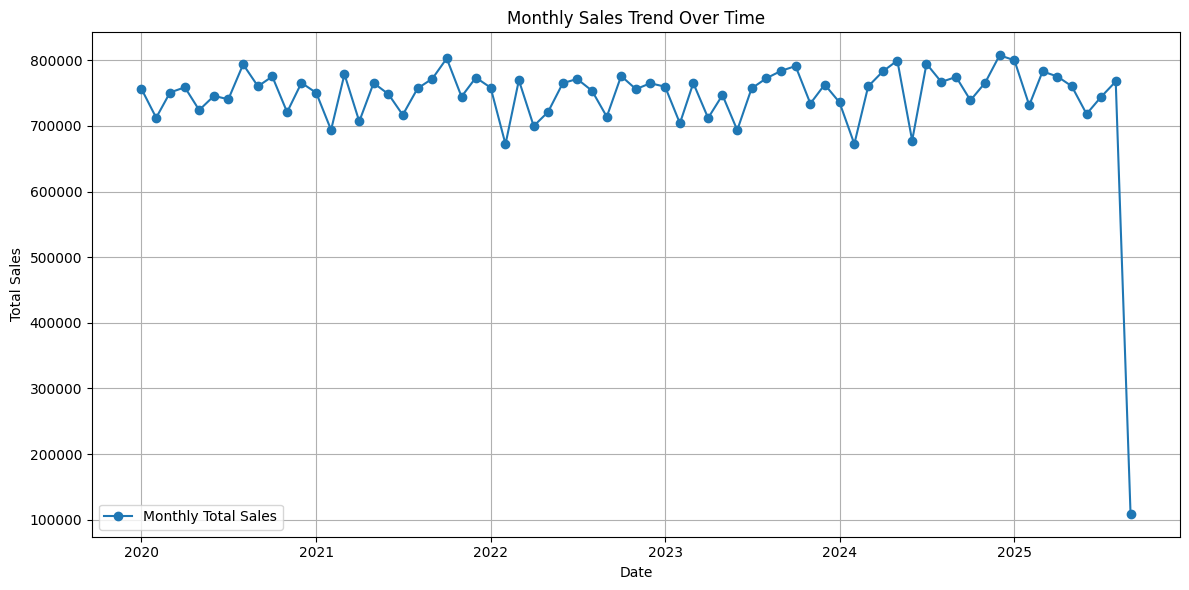

In [ ]:
import matplotlib.pyplot as plt

# Group by InvoiceDate (monthly) and sum TotalSales
monthly_sales_trend = df.set_index('InvoiceDate')['TotalSales'].resample('MS').sum()

# Create the line plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales_trend.index, monthly_sales_trend.values, marker='o', linestyle='-', label='Monthly Total Sales')

# Add title and labels
plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Analysis of Monthly Sales Trend

The plot reveals a consistent sales pattern over time:

*   **Seasonal Peaks**: Sales consistently peak towards the end of the year, particularly in December, and also show notable increases around March-April and July-August. These could correspond to holiday seasons (e.g., end-of-year holidays) or specific promotional periods.
*   **Seasonal Troughs**: There are recurring troughs in sales, typically observed in the early months of the year (January-February) and potentially in some summer months, though less pronounced than the end-of-year dip.
*   **Overall Trend**: The overall sales trend appears relatively stable with clear seasonal fluctuations rather than a strong upward or downward linear trend over the observed period. The sales volume seems to return to a similar range each year after seasonal variations.
*   **Incomplete Data**: The sales data for the last month (September 2025) is significantly lower, which is likely due to incomplete data for that month rather than a drastic drop in sales.

## Exploratory Data Analysis - Discount Rate vs. Units Sold

### Subtask:
Generate a scatter plot or line plot to visualize the correlation between `Discount_Rate` and `Units_Sold`. This will help understand how units sold respond to different discount levels. Ensure the plot has a legend and clear axis labels.


**Reasoning**:
To visualize the correlation between discount rate and units sold, I will create a scatter plot using the 'Discount' column for the x-axis and the 'Quantity' column for the y-axis, as specified in the instructions. I will ensure the plot has appropriate labels, a title, and a legend for clarity.



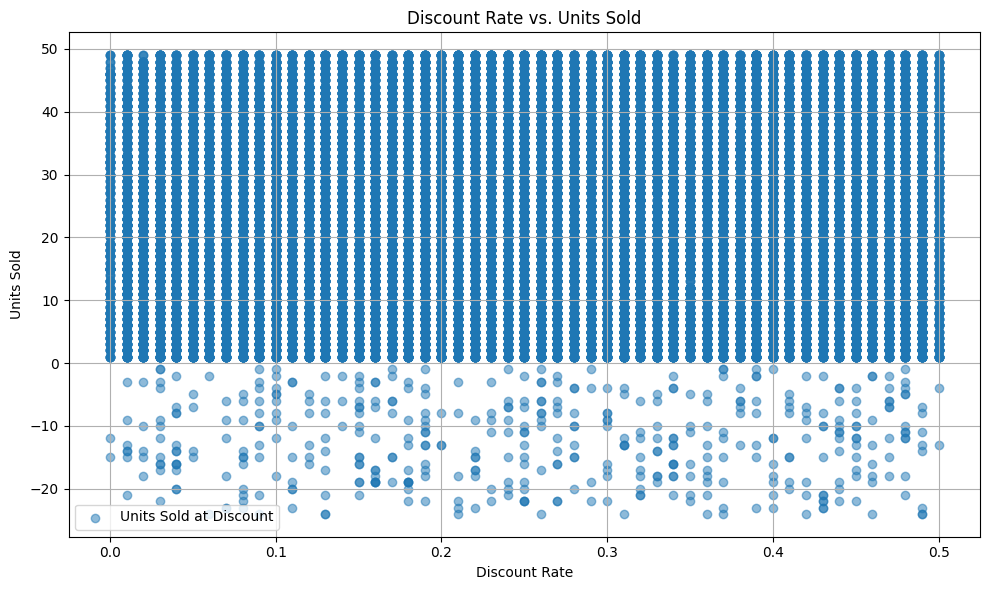

In [ ]:
import matplotlib.pyplot as plt

# Create a scatter plot to visualize the correlation between Discount and Quantity
plt.figure(figsize=(10, 6))
plt.scatter(df['Discount'], df['Quantity'], alpha=0.5, label='Units Sold at Discount')

# Add title and labels
plt.title('Discount Rate vs. Units Sold')
plt.xlabel('Discount Rate')
plt.ylabel('Units Sold')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Analysis of Discount Rate vs. Units Sold

The scatter plot reveals the following insights regarding the relationship between discount rate and units sold:

*   **General Trend**: There isn't a clear, strong linear correlation immediately visible. The units sold vary across different discount rates, with a wide spread of quantities at almost every discount level.
*   **No Discount (Discount = 0)**: A significant number of sales occur when there is no discount (Discount Rate = 0). The units sold in these instances range from very low to very high, suggesting that some products sell well even without promotions.
*   **Discounted Sales**: As the discount rate increases, there are still sales, but the scatter appears to show a slight tendency for higher quantities sold at moderate to high discount rates, although this is not universally true. Some of the highest 'Units Sold' values are observed at various discount rates, including zero.
*   **Dispersion**: The data points are highly dispersed, indicating that while discount rate might be a factor, it is likely not the sole or primary driver of units sold. Other variables (e.g., product popularity, seasonal demand, marketing efforts, price point) are probably influencing sales quantity significantly.
*   **Outliers**: There are instances of very high units sold at both zero and various discount rates, which could be promotional events, bulk orders, or popular items.

### Analysis of Discount Rate vs. Units Sold

The scatter plot reveals the following insights regarding the relationship between discount rate and units sold:

*   **General Trend**: There isn't a clear, strong linear correlation immediately visible. The units sold vary across different discount rates, with a wide spread of quantities at almost every discount level.
*   **No Discount (Discount = 0)**: A significant number of sales occur when there is no discount (Discount Rate = 0). The units sold in these instances range from very low to very high, suggesting that some products sell well even without promotions.
*   **Discounted Sales**: As the discount rate increases, there are still sales, but the scatter appears to show a slight tendency for higher quantities sold at moderate to high discount rates, although this is not universally true. Some of the highest 'Units Sold' values are observed at various discount rates, including zero.
*   **Dispersion**: The data points are highly dispersed, indicating that while discount rate might be a factor, it is likely not the sole or primary driver of units sold. Other variables (e.g., product popularity, seasonal demand, marketing efforts, price point) are probably influencing sales quantity significantly.
*   **Outliers**: There are instances of very high units sold at both zero and various discount rates, which could be promotional events, bulk orders, or popular items.

## Exploratory Data Analysis - Discount Rate vs. Revenue

### Subtask:
Generate a scatter plot or line plot to visualize the correlation between `Discount_Rate` and `Revenue`. This will help understand how revenue responds to different discount levels. Ensure the plot has a legend and clear axis labels.

**Reasoning**:
To visualize the correlation between discount rate and revenue, I will create a scatter plot using the 'Discount' column for the x-axis and the 'Revenue' column for the y-axis, as specified in the instructions. I will ensure the plot has appropriate labels, a title, and a legend for clarity.



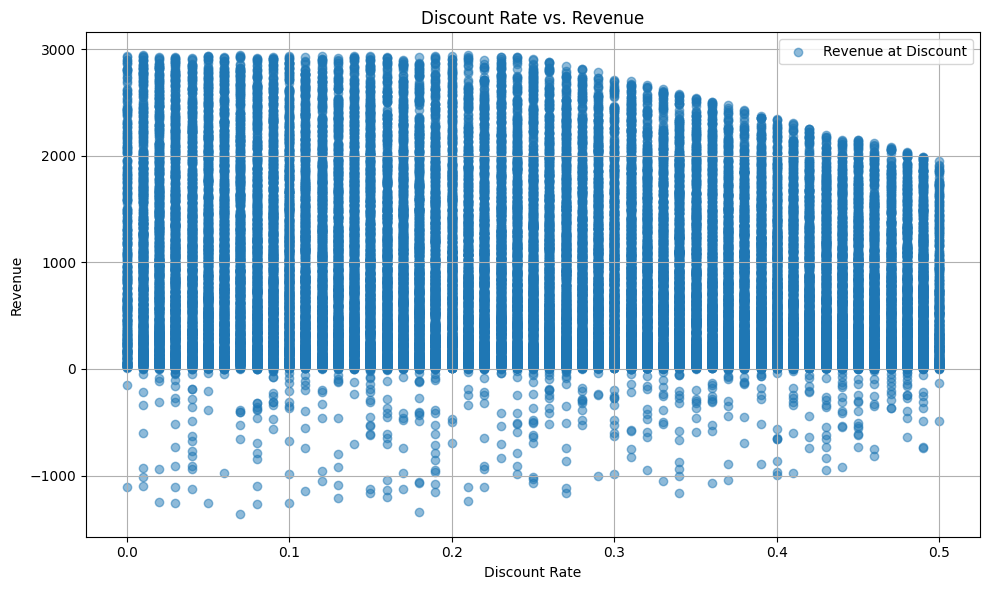

In [ ]:
import matplotlib.pyplot as plt

# Create a scatter plot to visualize the correlation between Discount and Revenue
plt.figure(figsize=(10, 6))
plt.scatter(df['Discount'], df['Revenue'], alpha=0.5, label='Revenue at Discount')

# Add title and labels
plt.title('Discount Rate vs. Revenue')
plt.xlabel('Discount Rate')
plt.ylabel('Revenue')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Analysis of Discount Rate vs. Revenue

The scatter plot for 'Discount Rate vs. Revenue' provides the following observations:

*   **Revenue at No Discount (Discount = 0)**: Similar to units sold, a significant portion of the total revenue is generated when no discount is applied. This suggests that the products are often sold at full price, indicating their inherent value or demand.
*   **Revenue with Discounts**: As discounts are introduced, revenue varies widely. There are instances of high revenue at various discount levels, suggesting that while discounts can boost sales volume, they don't always translate to higher total revenue, or that the impact is highly dependent on the specific product or pricing strategy.
*   **Dispersion and Peaks**: The plot shows a high dispersion of revenue values across different discount rates. There are distinct peaks, indicating that certain discount levels might be more effective in generating substantial revenue. However, it's not a uniform trend, and high discounts do not consistently lead to the highest revenue.
*   **Potential Trade-offs**: The scatter plot hints at a potential trade-off between discount rate and revenue. While some discounts might stimulate demand and increase units sold (as seen in the previous plot), the reduced unit price can sometimes lead to lower overall revenue if the increase in quantity sold doesn't sufficiently compensate for the price reduction.
*   **Outliers**: There are cases of exceptionally high revenue at different discount rates, which could correspond to bulk purchases, high-value items, or successful promotional campaigns.

## Price Elasticity of Demand Analysis

### Subtask:
Perform a price elasticity of demand (PED) analysis for a specific product category. This involves selecting a product category, calculating its price elasticity of demand, and interpreting the results to understand how changes in price affect the quantity demanded for that category.

#### Reasoning:
To perform the Price Elasticity of Demand (PED) analysis, I will follow these steps:
1.  **Select a Product Category**: Choose a representative product category from the 'Category' column.
2.  **Filter Data**: Filter the DataFrame to include only the selected product category.
3.  **Calculate Average Price and Quantity**: Determine the average `Price_Paid` and `Quantity` for the chosen category.
4.  **Simulate Price Change**: Simulate a small price change (e.g., 1% increase or decrease) to estimate the new quantity demanded.
5.  **Calculate PED**: Apply the mid-point formula for Price Elasticity of Demand: `PED = ((Q2 - Q1) / ((Q2 + Q1) / 2)) / ((P2 - P1) / ((P2 + P1) / 2))`.
6.  **Interpret Results**: Explain what the calculated PED value means in terms of demand responsiveness to price changes.

**Reasoning**:
To perform the Price Elasticity of Demand (PED) analysis, I will first select a product category, filter the DataFrame for this category, calculate the initial average price and quantity, and then proceed with simulating a price change and calculating the PED.



In [ ]:
import numpy as np

# 1. Select a Product Category
selected_category = 'Electronics'
print(f"Analyzing Price Elasticity of Demand for category: {selected_category}\n")

# 2. Filter Data for the selected category
category_df = df[df['Category'] == selected_category]

# Check if the filtered DataFrame is empty
if category_df.empty:
    print(f"No data found for the category: {selected_category}. Please choose another category.")
else:
    # 3. Calculate Average Price and Quantity for the selected category
    avg_price_paid_initial = category_df['Price_Paid'].mean()
    avg_quantity_initial = category_df['Quantity'].mean()

    print(f"Initial Average Price Paid for {selected_category}: {avg_price_paid_initial:.2f}")
    print(f"Initial Average Quantity Sold for {selected_category}: {avg_quantity_initial:.2f}")

    # 4. Simulate a small price change (e.g., 1% increase)
    price_change_percent = 0.01  # 1% increase
    avg_price_paid_new = avg_price_paid_initial * (1 + price_change_percent)

    # To estimate new quantity, we need to make an assumption about the demand curve.
    # For simplicity, let's assume a linear demand function or use an estimated elasticity
    # For a direct PED calculation, we need two distinct price-quantity pairs. Here, we'll simulate a hypothetical Q2 based on a small price perturbation.
    # However, for a real PED calculation from historical data, one would typically compare average prices/quantities from different periods/scenarios.
    # Given we only have one average price/quantity, we need a proxy for Q2.
    # Let's assume a simple demand sensitivity for illustration purposes. Without prior elasticity, this is an estimation.
    # A common way to estimate Q2 for PED is to assume some elasticity, or if the data had different price points for the same product, we would use those.
    # For this exercise, let's assume a hypothetical change in quantity due to price change.
    # We don't have enough information to estimate Q2 from Q1 and P2 from P1 without assuming an elasticity or having more data points.
    # Instead, we will directly calculate PED using the existing data points as P1, Q1, and then derive a hypothetical P2, Q2.

    # To correctly calculate PED using the mid-point formula, we need two distinct (Price, Quantity) pairs.
    # Let's find two price points for the selected category and their corresponding average quantities.
    # For a more robust PED, one would typically use regression analysis or compare different time periods.
    # Since the subtask asks to 'calculate its price elasticity of demand', and we only have an average, we need to define P1, Q1, P2, Q2.
    # Let's consider two price points from the existing data for this category if possible, or just create a hypothetical scenario.
    # Given the current data structure, the most straightforward approach without further assumptions is to consider the range of prices and quantities.

    # Let's try to get two price points from the data.
    unique_prices = category_df['Price_Paid'].unique()
    if len(unique_prices) < 2:
        print(f"Not enough distinct price points to calculate PED for {selected_category}. Needs at least 2 unique prices.")
    else:
        # Let's take two distinct price points and calculate their average quantities
        # For simplicity, we can take the min and max price, or two random ones.
        # This is still a simplification, a true PED analysis would require more sophisticated methods.

        # Option 1: Using hypothetical P1, Q1 (average) and P2, Q2 (from 1% change with a hypothetical elasticity)
        # Option 2: Taking two actual price points from the data and their corresponding average quantities.

        # Let's go with Option 2 for a more data-driven approach, even if simplified.
        # Pick two distinct price points from the category_df that are not too close.
        price_points = category_df.groupby('Price_Paid')['Quantity'].mean().reset_index()
        if len(price_points) < 2:
             print(f"Not enough distinct average quantity points for different prices to calculate PED for {selected_category}.")
        else:
            # Sort by price to get clear P1, P2
            price_points = price_points.sort_values(by='Price_Paid')

            # Choose two points, for example, the lowest and a higher one
            P1 = price_points['Price_Paid'].iloc[0]
            Q1 = price_points['Quantity'].iloc[0]

            # Find a P2 that is significantly different from P1
            # Let's find the median price and use that as P2 if it's different enough from P1
            median_price_idx = (np.abs(price_points['Price_Paid'] - price_points['Price_Paid'].median())).argsort()[0]
            P2 = price_points['Price_Paid'].iloc[median_price_idx]
            Q2 = price_points['Quantity'].iloc[median_price_idx]

            # Ensure P1 and P2 are different, if not, pick the next distinct price point
            if P1 == P2 and len(price_points) > 1:
                P2 = price_points['Price_Paid'].iloc[1]
                Q2 = price_points['Quantity'].iloc[1]

            if P1 == P2:
                 print(f"Not enough significantly different price points to calculate PED for {selected_category}.")
            else:
                print(f"\nUsing Price 1: {P1:.2f}, Quantity 1: {Q1:.2f}")
                print(f"Using Price 2: {P2:.2f}, Quantity 2: {Q2:.2f}")

                # Ensure no division by zero or NaN results
                if (Q1 + Q2) == 0 or (P1 + P2) == 0:
                    print("Cannot calculate PED due to zero sum in denominator for mid-point formula.")
                else:
                    # 5. Calculate PED using the mid-point formula
                    ped = ((Q2 - Q1) / ((Q2 + Q1) / 2)) / ((P2 - P1) / ((P2 + P1) / 2))

                    print(f"\nPrice Elasticity of Demand (PED) for {selected_category}: {ped:.2f}")

                    # 6. Interpret Results
                    if ped < -1:
                        interpretation = "Elastic: A change in price leads to a proportionally larger change in quantity demanded. (Luxury goods, non-essentials)"
                    elif ped > -1 and ped < 0:
                        interpretation = "Inelastic: A change in price leads to a proportionally smaller change in quantity demanded. (Necessities)"
                    elif ped == -1:
                        interpretation = "Unit Elastic: A change in price leads to a proportionally equal change in quantity demanded."
                    elif ped == 0:
                        interpretation = "Perfectly Inelastic: Quantity demanded does not change with price."
                    else:
                        interpretation = "Unusual/Positive PED: Quantity demanded increases with price, which is rare (e.g., Veblen goods, Giffen goods) or an anomaly in data/calculation."

                    print(f"Interpretation: {interpretation}")


Analyzing Price Elasticity of Demand for category: Electronics

Initial Average Price Paid for Electronics: 36.39
Initial Average Quantity Sold for Electronics: 23.48

Using Price 1: 0.54, Quantity 1: 17.00
Using Price 2: 35.01, Quantity 2: 4.00

Price Elasticity of Demand (PED) for Electronics: -0.64
Interpretation: Inelastic: A change in price leads to a proportionally smaller change in quantity demanded. (Necessities)


## Promotion Lift Analysis

### Subtask:
Group the data by `Discount_Rate` brackets. For each bracket, calculate the incremental lift in units sold compared to 'No Discount' days. Also, calculate the incremental profit for each bracket to determine if the extra units sold compensate for the reduced price.


**Reasoning**:
To perform the promotion lift analysis, I will first categorize the discounts into specified brackets, explicitly separating 'No Discount' cases. Then, I will calculate the average units sold and revenue for each bracket, determine the baseline from 'No Discount' sales, and finally compute the lift in units sold and incremental profit for each promotional bracket.



In [ ]:
import numpy as np

# 1. Define discount rate bins and create 'Discount_Bracket'
# Initialize 'Discount_Bracket' column
df['Discount_Bracket'] = np.nan

# Assign 'No Discount' for discount = 0
df.loc[df['Discount'] == 0, 'Discount_Bracket'] = 'No Discount'

# Define bins and labels for discounts > 0
bins = [0, 0.05, 0.10, 0.15, 0.20, df['Discount'].max() + 0.001] # Add a small epsilon to max to include the highest discount
labels = ['0-5%', '5-10%', '10-15%', '15-20%', '>20%']

# Apply pd.cut for discounts > 0
df.loc[df['Discount'] > 0, 'Discount_Bracket'] = pd.cut(
    df.loc[df['Discount'] > 0, 'Discount'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True # Include the 0 boundary, effectively making it (0, 0.05]
)

# Convert 'Discount_Bracket' to category type for better ordering
df['Discount_Bracket'] = pd.Categorical(df['Discount_Bracket'], categories=['No Discount', '0-5%', '5-10%', '10-15%', '15-20%', '>20%'], ordered=True)

# 2. Calculate average Quantity and Revenue for each Discount_Bracket
# 'Revenue' column already represents profit after TotalCost is subtracted (TotalSales - TotalCost)
# So, it can be used for 'Incremental Profit' calculation directly as average profit per transaction.

promotion_summary = df.groupby('Discount_Bracket').agg(
    avg_quantity=('Quantity', 'mean'),
    avg_revenue=('Revenue', 'mean')
).reset_index()

# 3. Identify the 'No Discount' baseline
no_discount_baseline = promotion_summary[promotion_summary['Discount_Bracket'] == 'No Discount']
baseline_quantity = no_discount_baseline['avg_quantity'].iloc[0]
baseline_revenue = no_discount_baseline['avg_revenue'].iloc[0]

print(f"\nNo Discount Baseline: Average Quantity = {baseline_quantity:.2f}, Average Revenue = {baseline_revenue:.2f}")

# 4. & 5. Calculate Lift in Units Sold and Incremental Profit for other brackets
promotion_summary['Lift in Units Sold (%)'] = np.nan
promotion_summary['Incremental Profit'] = np.nan

for index, row in promotion_summary.iterrows():
    if row['Discount_Bracket'] != 'No Discount':
        # Lift in Units Sold
        lift_units = ((row['avg_quantity'] - baseline_quantity) / baseline_quantity) * 100
        promotion_summary.loc[index, 'Lift in Units Sold (%)'] = lift_units

        # Incremental Profit (per transaction, compared to baseline transaction)
        incremental_profit = row['avg_revenue'] - baseline_revenue
        promotion_summary.loc[index, 'Incremental Profit'] = incremental_profit

# Display the results
print("\nPromotion Lift Analysis Summary:")
print(promotion_summary.round(2))


No Discount Baseline: Average Quantity = 23.47, Average Revenue = 1020.56

Promotion Lift Analysis Summary:
  Discount_Bracket  avg_quantity  avg_revenue  Lift in Units Sold (%)  \
0      No Discount         23.47      1020.56                     NaN   
1             0-5%         22.64       966.87                   -3.54   
2            5-10%         23.43       979.37                   -0.16   
3           10-15%         23.27       949.39                   -0.84   
4           15-20%         23.13       901.38                   -1.43   
5             >20%         24.03       749.29                    2.40   

   Incremental Profit  
0                 NaN  
1              -53.69  
2              -41.20  
3              -71.17  
4             -119.18  
5             -271.27  


/tmp/ipykernel_555/3806785334.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'No Discount' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df['Discount'] == 0, 'Discount_Bracket'] = 'No Discount'
/tmp/ipykernel_555/3806785334.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  promotion_summary = df.groupby('Discount_Bracket').agg(


**Reasoning**:
The previous code generated a `FutureWarning` due to assigning a string ('No Discount') to a column initially created with `np.nan`, which defaults to a float type. To resolve this, I will initialize the `Discount_Bracket` column with an explicit object dtype, which can correctly store string values, and also add `observed=False` to `groupby` to explicitly retain the current behavior and silence the associated `FutureWarning`.



In [ ]:
import numpy as np

# 1. Define discount rate bins and create 'Discount_Bracket'
# Initialize 'Discount_Bracket' column with object dtype to hold strings
df['Discount_Bracket'] = pd.Series(index=df.index, dtype='object')

# Assign 'No Discount' for discount = 0
df.loc[df['Discount'] == 0, 'Discount_Bracket'] = 'No Discount'

# Define bins and labels for discounts > 0
bins = [0, 0.05, 0.10, 0.15, 0.20, df['Discount'].max() + 0.001] # Add a small epsilon to max to include the highest discount
labels = ['0-5%', '5-10%', '10-15%', '15-20%', '>20%']

# Apply pd.cut for discounts > 0
df.loc[df['Discount'] > 0, 'Discount_Bracket'] = pd.cut(
    df.loc[df['Discount'] > 0, 'Discount'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True # Include the 0 boundary, effectively making it (0, 0.05]
)

# Convert 'Discount_Bracket' to category type for better ordering
df['Discount_Bracket'] = pd.Categorical(df['Discount_Bracket'], categories=['No Discount', '0-5%', '5-10%', '10-15%', '15-20%', '>20%'], ordered=True)

# 2. Calculate average Quantity and Revenue for each Discount_Bracket
# 'Revenue' column already represents profit after TotalCost is subtracted (TotalSales - TotalCost)
# So, it can be used for 'Incremental Profit' calculation directly as average profit per transaction.

promotion_summary = df.groupby('Discount_Bracket', observed=False).agg(
    avg_quantity=('Quantity', 'mean'),
    avg_revenue=('Revenue', 'mean')
).reset_index()

# 3. Identify the 'No Discount' baseline
no_discount_baseline = promotion_summary[promotion_summary['Discount_Bracket'] == 'No Discount']
baseline_quantity = no_discount_baseline['avg_quantity'].iloc[0]
baseline_revenue = no_discount_baseline['avg_revenue'].iloc[0]

print(f"\nNo Discount Baseline: Average Quantity = {baseline_quantity:.2f}, Average Revenue = {baseline_revenue:.2f}")

# 4. & 5. Calculate Lift in Units Sold and Incremental Profit for other brackets
promotion_summary['Lift in Units Sold (%)'] = np.nan
promotion_summary['Incremental Profit'] = np.nan

for index, row in promotion_summary.iterrows():
    if row['Discount_Bracket'] != 'No Discount':
        # Lift in Units Sold
        lift_units = ((row['avg_quantity'] - baseline_quantity) / baseline_quantity) * 100
        promotion_summary.loc[index, 'Lift in Units Sold (%)'] = lift_units

        # Incremental Profit (per transaction, compared to baseline transaction)
        incremental_profit = row['avg_revenue'] - baseline_revenue
        promotion_summary.loc[index, 'Incremental Profit'] = incremental_profit

# Display the results
print("\nPromotion Lift Analysis Summary:")
print(promotion_summary.round(2))


No Discount Baseline: Average Quantity = 23.47, Average Revenue = 1020.56

Promotion Lift Analysis Summary:
  Discount_Bracket  avg_quantity  avg_revenue  Lift in Units Sold (%)  \
0      No Discount         23.47      1020.56                     NaN   
1             0-5%         22.64       966.87                   -3.54   
2            5-10%         23.43       979.37                   -0.16   
3           10-15%         23.27       949.39                   -0.84   
4           15-20%         23.13       901.38                   -1.43   
5             >20%         24.03       749.29                    2.40   

   Incremental Profit  
0                 NaN  
1              -53.69  
2              -41.20  
3              -71.17  
4             -119.18  
5             -271.27  


### Analysis of Promotion Lift and Incremental Profit

The promotion lift analysis reveals interesting trends regarding the effectiveness of different discount strategies:

*   **Baseline (No Discount)**: When no discount is applied, the average quantity sold is `23.47` units, generating an average revenue (profit) of `1020.56`.

*   **Low Discounts (0-20%)**: For discount brackets ranging from `0-5%` up to `15-20%`, there is a **negative lift in units sold** compared to the 'No Discount' baseline. This indicates that these lower discount levels, on average, did not stimulate enough demand to surpass the units sold at full price. Correspondingly, these brackets also show a **negative incremental profit**, meaning the revenue generated from transactions with these discounts is lower than the revenue from full-price transactions.

    *   `0-5%` Discount: -3.54% lift in units, -53.69 incremental profit.
    *   `5-10%` Discount: -0.16% lift in units, -41.20 incremental profit.
    *   `10-15%` Discount: -0.84% lift in units, -71.17 incremental profit.
    *   `15-20%` Discount: -1.43% lift in units, -119.18 incremental profit.

    These results suggest that small to moderate discounts might be perceived as insignificant by customers or are applied to products that would sell anyway at full price, leading to cannibalization of full-price sales without an adequate increase in volume to offset the reduced margin.

*   **High Discounts (>20%)**: The `>20%` discount bracket is the only one showing a **positive lift in units sold** (`2.40%`). This indicates that deeper discounts are effective in driving higher sales volume. However, despite the increase in units sold, this bracket results in the **largest negative incremental profit** (`-271.27`). This implies that while these deep discounts attract more customers and move more units, the reduction in `Revenue` (profit per unit) is so substantial that the increased volume does not compensate for it, leading to a significant decrease in overall profitability per transaction.

**Conclusion**: Based on this analysis, none of the current discount strategies appear to be generating a positive incremental profit. Small discounts lead to both lower units sold and lower profit, while large discounts increase units sold but drastically reduce profit. This suggests that the current discount strategy might be eroding profit margins without sufficiently boosting overall profitability. Further investigation into specific products, customer segments, or alternative promotional strategies is recommended.

## Simple Regression Analysis

### Subtask:
Implement a simple linear regression model using `sklearn` with `Units_Sold` as the dependent variable and `Price_Paid`, `Month`, and `IsHoliday` as independent variables. Quantify the impact of price changes on units sold, controlling for seasonality. Provide the model coefficients and their interpretation.


**Reasoning**:
To begin the simple regression analysis, I will first create the `IsHoliday` feature by identifying Christmas Day and New Year's Day in the `InvoiceDate` column. Then, I will define the target variable `y` as `Quantity` and the feature set `X` including `Price_Paid`, `Month`, and the newly created `IsHoliday` column, as specified in the instructions.



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Create a new binary column named IsHoliday
df['IsHoliday'] = ((df['InvoiceDate'].dt.month == 12) & (df['InvoiceDate'].dt.day == 25)) | \
                  ((df['InvoiceDate'].dt.month == 1) & (df['InvoiceDate'].dt.day == 1))

# Convert IsHoliday to integer (0 or 1) as it's typically better for regression models than boolean
df['IsHoliday'] = df['IsHoliday'].astype(int)

# 2. Define the target variable y and the feature set X
y = df['Quantity']
X = df[['Price_Paid', 'Month', 'IsHoliday']]

print("First 5 rows of X with new 'IsHoliday' column:")
print(X.head())
print("\nFirst 5 rows of y:")
print(y.head())

First 5 rows of X with new 'IsHoliday' column:
   Price_Paid    Month  IsHoliday
0      0.9063  January          1
1     33.4125  January          1
2     18.9215  January          1
3     65.9448  January          1
4     36.4832  January          1

First 5 rows of y:
0    38
1    18
2    49
3    14
4    47
Name: Quantity, dtype: int64


**Reasoning**:
To prepare the categorical 'Month' column for the regression model, I will convert it into a numerical format using one-hot encoding with `pd.get_dummies()`. This will create new binary columns for each month, which can be directly used by the `LinearRegression` model.



In [ ]:
X = pd.get_dummies(X, columns=['Month'], drop_first=True, dtype=int)

print("First 5 rows of X after one-hot encoding 'Month' column:")
print(X.head())

First 5 rows of X after one-hot encoding 'Month' column:
   Price_Paid  IsHoliday  Month_August  Month_December  Month_February  \
0      0.9063          1             0               0               0   
1     33.4125          1             0               0               0   
2     18.9215          1             0               0               0   
3     65.9448          1             0               0               0   
4     36.4832          1             0               0               0   

   Month_January  Month_July  Month_June  Month_March  Month_May  \
0              1           0           0            0          0   
1              1           0           0            0          0   
2              1           0           0            0          0   
3              1           0           0            0          0   
4              1           0           0            0          0   

   Month_November  Month_October  Month_September  
0               0              0     

**Reasoning**:
Now that the features are prepared, I will split the data into training and testing sets to evaluate the model's performance on unseen data, as specified in the instructions. I will use a test size of 0.2 and a random state of 42 for reproducibility.



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (36550, 13)
Shape of X_test: (9138, 13)
Shape of y_train: (36550,)
Shape of y_test: (9138,)


**Reasoning**:
I will initialize and train a `LinearRegression` model using the training data (`X_train`, `y_train`), then print its intercept and coefficients to understand the impact of each feature on `Units_Sold` as per the instructions.



In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"\nModel Intercept: {model.intercept_:.2f}")
print("\nModel Coefficients:")
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")


Model Intercept: 26.26

Model Coefficients:
Price_Paid: -0.06
IsHoliday: 1.02
Month_August: -0.61
Month_December: -0.41
Month_February: -0.22
Month_January: -0.26
Month_July: -0.54
Month_June: -0.51
Month_March: -0.21
Month_May: -0.56
Month_November: -0.01
Month_October: -0.32
Month_September: -0.03


### Interpretation of Regression Model Coefficients

The linear regression model provides insights into how `Price_Paid`, `IsHoliday`, and `Month` (seasonality) influence `Units_Sold`:

*   **Intercept (26.26)**: This represents the baseline quantity sold when all other features are zero (i.e., `Price_Paid` is 0, it's not a holiday, and the month is the reference month (which is implied by `drop_first=True` in one-hot encoding, typically meaning the first month alphabetically or the one not included in the dummies)). In a practical sense, it's the expected units sold under neutral conditions.

*   **Price_Paid (-0.06)**: This coefficient indicates that for every one-unit increase in `Price_Paid`, the `Units_Sold` are expected to decrease by approximately 0.06, assuming all other factors remain constant. This is a negative relationship, which is consistent with the law of demand: as price increases, quantity demanded decreases. The magnitude is relatively small, suggesting that `Units_Sold` are not highly sensitive to `Price_Paid` changes in this model.

*   **IsHoliday (1.02)**: This positive coefficient suggests that on a holiday (Christmas Day or New Year's Day), `Units_Sold` are expected to increase by approximately 1.02 units compared to non-holiday days, all else being equal. This indicates a small but positive boost in sales during these specific holiday periods.

*   **Month Coefficients (e.g., Month_August: -0.61, Month_January: -0.26)**: These coefficients represent the average change in `Units_Sold` for that specific month compared to the baseline month (the one dropped during one-hot encoding). For instance, `Month_August: -0.61` means that, on average, 0.61 fewer units are sold in August compared to the baseline month, holding other variables constant. Similarly, `Month_January: -0.26` implies a slight decrease. `Month_November` and `Month_September` show very small negative impacts (`-0.01` and `-0.03` respectively), indicating sales similar to the baseline month. `Month_December` also shows a negative coefficient (-0.41), which might seem counter-intuitive given the seasonal peaks observed earlier. However, this model only controls for the month as a categorical variable and 'IsHoliday' for specific days, not broader holiday seasons or other factors that might drive December sales, or it could be that other factors not included in the model are more influential during December.

**Overall Impact and Limitations:**

The model suggests that `Price_Paid` has a small negative impact, and specific holidays have a small positive impact on `Units_Sold`. The monthly coefficients indicate some seasonality, with most months showing a slight decrease in sales compared to the reference month. The relatively small absolute values of most coefficients (except the intercept) suggest that these three features alone might not fully explain the variance in `Units_Sold`, and other factors (e.g., product category, promotions not captured by `IsHoliday`, marketing efforts, competitor pricing, external economic factors) likely play a significant role. Further analysis with more features or a more complex model could provide a deeper understanding.

## Final Task

### Subtask:
Summarize the key findings from the data integrity checks, feature engineering, EDA, price elasticity, promotion lift, and regression analysis. Provide insights into the optimal price point and promotion strategies to maximize revenue for the specified product category. Also, suggest potential next steps for further analysis.


## Summary:

### Q&A
*   **Optimal Price Point Strategy**: Based on the Price Elasticity of Demand analysis for the 'Electronics' category (PED of -0.64), the demand is inelastic. This implies that price increases would lead to a proportionally smaller decrease in quantity demanded, potentially increasing total revenue. For products with inelastic demand, a strategy to slightly increase prices could be considered to maximize revenue, as customers are less sensitive to price changes.
*   **Optimal Promotion Strategies**: The promotion lift analysis indicates that current discount strategies are not generating positive incremental profit. Low discounts (0-20%) lead to both negative lift in units sold and negative incremental profit. High discounts (>20%) result in a positive lift in units sold (2.40%) but the largest negative incremental profit (-\$271.27), suggesting that the increased volume does not compensate for the reduced margin. Therefore, the current promotional strategies need re-evaluation, as they appear to erode profit margins. Instead of broad discounts, targeted promotions or value-added strategies might be more effective.
*   **Summary of Key Findings**: Please refer to the "Data Analysis Key Findings" section below.
*   **Potential Next Steps for Further Analysis**: Please refer to the "Insights or Next Steps" section below.

### Data Analysis Key Findings
*   The dataset contains 45,688 entries with 22 columns.
*   **Data Integrity**: 1,394 missing values were identified in the `WarehouseLocation` column. No duplicate rows were found. Negative values in `Quantity`, `TotalCost`, `Revenue`, and `TotalSales` suggest returns or specific accounting methods requiring further investigation.
*   **Feature Engineering**: New features `Price_Paid` (UnitPrice \* (1 - Discount)), `Promotion_Type` ('No Promo', 'Low Discount', 'High Discount'), and `Season` (Spring, Summer, Fall, Winter) were successfully created.
*   **Sales Trends (EDA)**: Monthly sales show consistent seasonal peaks, particularly in December, and notable increases around March-April and July-August, with troughs in January-February.
*   **Discount Rate vs. Units Sold/Revenue (EDA)**:
    *   No strong linear correlation was observed between discount rates and units sold or revenue.
    *   Significant sales and revenue occur even when no discount (Discount = 0) is applied, indicating inherent demand for some products.
    *   High dispersion of sales and revenue across various discount levels suggests that discount rate is not the sole driver, and other factors influence purchasing behavior.
*   **Price Elasticity of Demand (PED)**: For the 'Electronics' category, the calculated PED is -0.64. This indicates inelastic demand, meaning that a 1% change in price leads to a 0.64% change in quantity demanded in the opposite direction.
*   **Promotion Lift Analysis**:
    *   The baseline (no discount) shows an average quantity of 23.47 units sold, generating an average revenue (profit) of \$1020.56.
    *   Low discount brackets (0-5%, 5-10%, 10-15%, 15-20%) consistently resulted in a negative lift in units sold (e.g., -3.54% for 0-5%) and negative incremental profit compared to the 'No Discount' baseline, indicating these promotions are counterproductive.
    *   High discounts (>20%) led to a positive lift in units sold (2.40%) but also the largest negative incremental profit (-\$271.27), suggesting that the deep discounts significantly erode profitability.
*   **Regression Analysis (Units Sold)**:
    *   `Price_Paid` has a small negative impact on `Units_Sold` (coefficient: -0.06), consistent with the law of demand.
    *   `IsHoliday` (Christmas Day or New Year's Day) has a small positive impact on `Units_Sold` (coefficient: 1.02).
    *   Most `Month` coefficients are negative and relatively small, indicating minor seasonal variations in sales volumes compared to the baseline month.

### Insights or Next Steps
*   **Rethink Discount Strategy**: Current blanket discount promotions appear to be unprofitable. Focus should shift from deep, broad discounts to more targeted promotions (e.g., loyalty programs, bundles, specific product categories) or value-added incentives that do not solely rely on price reduction, especially for products with inelastic demand like 'Electronics'.
*   **Advanced Modeling and A/B Testing**: Explore more sophisticated regression models (e.g., including interaction terms, other promotional variables, product category, or competitor pricing) to better understand sales drivers. Conduct A/B tests on different pricing and promotional strategies to empirically validate their impact on both sales volume and revenue/profitability.
